# S&P 500 Equity+Options: Patched Attention

[`09_dl_lstm`](09_dl_lstm.ipynb) fitted the two sequence architectures that read a window one
observation at a time: a linear map with no memory, and gated memory carried along the window.
This notebook fits the third the menu declares, which reads the same window a different way.

**A patched transformer cuts the window into contiguous blocks and treats each block as one
token.** Sixty observations become a handful of patches, and attention runs over those patches
rather than over the sixty steps. Two things follow. Attention compares every patch with every
other directly, so a relationship between the start of the window and its end does not have to
survive being carried step by step the way it does in a recurrent model. And the sequence the
attention layers see is short, which is what makes attention affordable on a window of this length
at all.

**The patch size is the modelling choice, and it is a coarseness decision.** Observations inside
one patch are summarized together before attention ever sees them, so structure finer than a patch
has to survive that summary. A larger patch buys a shorter sequence and loses resolution; a
smaller one keeps resolution and gives attention more to compare.

**This architecture is declared on one label, and that limits what the notebook can say.** The
menu declares `patchtst` for the primary label alone, so unlike its siblings this population has
no companion rows on the other two targets, and nothing here separates what the architecture does
from what this particular target rewards. Section 1 reports what the menu declares rather than
assuming it.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what patching does to a window before attention sees it, and what a larger patch trades
  away.
- Explain why attention over patches is affordable where attention over raw steps would not be.
- Read a curve of out-of-sample ranking accuracy against training epoch and tell a model still
  learning apart from one fitting its training window.
- Say what a single-label population cannot establish, and where the comparison that needs more
  than one label is made instead.

**Book reference**: Chapter 13, Section 13.6 (attention and transformer architectures for time
series), and Chapter 6, Section 6.7 (Search accounting and run logging) for the run log this
notebook writes into.

**Prerequisites**: [`05_evaluation`](05_evaluation.ipynb) established the walk-forward folds, and
[`09_dl_lstm`](09_dl_lstm.ipynb) fitted the rest of the declared `deep_learning` family, whose
lookback and epoch schedule this configuration shares.

**What it writes**: one training run and one complete validation prediction set per epoch
checkpoint, in `run_log/registry.db` and under `run_log/training/` and `run_log/predictions/`,
grouped under a named population. Together with `09_dl_lstm`'s population it covers the declared
family. **Selection happens in [`14_backtest`](14_backtest.ipynb), not here.**

In [1]:
"""Fit the declared option-analytics patched-transformer population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    primary_label,
    resolved_model_plan,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="10_dl_patchtst",
)

## 1. Which labels, and which model

`declared_labels` reports every label whose training menu declares `deep_learning`. The
configuration frame below is the subset of that menu naming `patchtst`, and the gap between the
two is the fact this notebook has to live with: the other architectures in the family are declared
on all three regression labels and this one is not.

`patch_size` is how many consecutive observations become one token, `d_model` the width of the
representation each token is embedded into, `n_heads` how many attention comparisons run in
parallel, and `n_layers` how many times the sequence is passed through the block. `lookback`
matches the rest of the family, so the input window is the same one `09_dl_lstm` read and a
difference between the populations is a difference between architectures rather than samples.

`n_epochs` and `checkpoint_interval` come from the preset rather than from here, because they
decide how many prediction sets the configuration owes: 100 epochs saved every 5 is 20, and a run
that quietly trained for fewer would publish a different population under the same name.

In [4]:
declared_labels(study, "deep_learning")

('fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d')

In [5]:
configs = load_model_configs(
    study,
    "deep_learning",
    labels=LABELS or None,
    config_names=["patchtst"],
)
declared = load_model_configs(study, "deep_learning", config_names=["patchtst"])
if not configs.height:
    raise RuntimeError("no declared label names patchtst under deep_learning")
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""deep_learning""","""fwd_ret_5d""","""patchtst""","""""","""architecture=patchtst, d_model…"


`LABELS` narrows the run below what the menu declares, and a narrowed run declares a different set
of members than the published population does. A population is immutable once written, so such a
run must publish under its own name rather than registering an incomplete snapshot under the
published one.

The device is checked in the same cell. A network trained on a GPU and the same network trained on
a CPU accumulate their sums in different orders and reach different weights, so the device is part
of what the fitted model is and is recorded inside the computation's identity rather than beside
it. The runner refuses to substitute a CPU for a requested GPU rather than publishing a different
model under the published name, so on a machine with no NVIDIA card this notebook stops at the
next cell; set `DEVICE="cpu"` and pass a `POPULATION_NAME` to fit the same configuration there.

In [6]:
PUBLISHED_DEVICE = "cuda"
device = DEVICE or PUBLISHED_DEVICE
print(f"training device: {device}")

narrows = set(zip(configs["label"], configs["config_name"], strict=True)) != set(
    zip(declared["label"], declared["config_name"], strict=True)
)
if (narrows or device != PUBLISHED_DEVICE) and not POPULATION_NAME:
    raise ValueError(
        f"this run declares {configs.height} label-configuration pairs on device {device!r}, "
        f"which is not the declared patchtst catalog on {PUBLISHED_DEVICE!r}, so it cannot "
        f"publish the patched-attention population; pass POPULATION_NAME to give it its own"
    )

training device: cuda


## 2. Binding the declaration to the data

A menu entry says which network to fit. It does not say which feature columns exist today, where
the walk-forward folds fall, or which symbol-date pairs have both a feature row and a label - nor,
for a sequence model, which of those pairs have a full lookback behind them. **Resolving** a
request goes and finds all of that, and fits nothing, so the plan can be inspected before any
training starts.

- **`eligible_rows` is below what a tabular family reports on the same label.** A prediction needs
  a full, gap-free window of prior observations behind it, so what drops out is a stock too new to
  have accumulated one, or a stretch where the calendar has a hole inside the window. It should
  match what `09_dl_lstm` reported for this label, because the two share a lookback - a difference
  would mean the two populations are measured on different samples and their results are not
  directly comparable.
- **`folds` equals the number of walk-forward splits** `05_evaluation` established.
- **`validation_start` and `validation_end` bracket the development sample.** The held-out tail
  must not appear here: it is scored once, at the end of the case study.
- **`checkpoints` is the epoch schedule**, and multiplying it by the number of rows gives the
  number of candidate models this notebook is about to create.

The `training_hash` on each row is the identity of that computation, derived from everything that
can change its result - the device, the lookback and the patch size included.
[`RUN_LOG.md`](../RUN_LOG.md#identity) sets out what goes into one.

In [7]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides={"device": device},
    preview_reductions=PREVIEW_REDUCTIONS,
)
resolved = tuple(request.resolve() for request in requests)

plan = resolved_model_plan(resolved)
plan.select(
    "label",
    "config_name",
    "feature_count",
    "eligible_entities",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,feature_count,eligible_entities,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,i64,i64,i64,i64,i64,datetime[μs],datetime[μs]
"""fwd_ret_5d""","""patchtst""",48,287,126185,2,20,2019-01-07 00:00:00,2020-12-23 00:00:00


## 3. Fitting the population

`run_model_population` walks the folds. On each one it cuts the training rows into overlapping
windows belonging to one stock and ending before the timestamp they predict, replaces missing
feature values with zero and standardizes each column - the mean and scale measured on the
training rows and applied unchanged to validation - then trains for the declared epochs, writing
weights every fifth, and predicts that fold's validation rows from each saved set.

**A window never crosses a stock, and it reads only what was observable.** The observations behind
a prediction are always that stock's own. They are not confined to the training window: each
stock's validation history is primed with the rows immediately preceding it, and later validation
dates read earlier validation rows - feature values already on the table at the timestamp being
predicted, never a label from the interval that prediction covers. The purge gap the folds impose
on labels is not crossed.

What the call publishes is a **population**: a named, immutable list of the prediction sets it is
going to produce, computed from the resolved specification before the first fit. Afterwards every
member must exist and be complete, which is why a failure fails the whole call rather than
publishing a population one member short. Everything that finished stays registered, and
re-running trains only what is missing.

`SUPERSEDES_POPULATION` names the population hash this run replaces, and is empty because this is
the first generation under this name. Anything that moves a training identity - a changed epoch
schedule, lookback, patch size or device - produces a different population under the same name,
and the registry refuses to write it without being told which snapshot it supersedes.

In [8]:
population_name = POPULATION_NAME or "sp500_equity_option_analytics-patchtst-validation-v1"
execution, population = run_model_population(
    study,
    resolved,
    population_name=population_name,
    supersedes=SUPERSEDES_POPULATION or None,
)

reused = sum(1 for item in execution.diagnostics if item.get("reused"))
print(
    f"{len(execution.runs)} configurations: {len(execution.runs) - reused} trained, {reused} read"
)
print(f"population {population.name}: {len(population.members)} prediction sets")

Fold-major CV: 2 folds × 1 configs × 60 lookback

  Fold 0: creating sequences...


    train=110,592 seq across 526 symbols
    val=61,696 seq across 513 symbols
    creating datasets...
    datasets ready
    patchtst:


      epoch   1/100: train_loss=0.021098


      epoch   2/100: train_loss=0.005036


      epoch   3/100: train_loss=0.002865


...

      epoch 100/100: train_loss=0.001332, val_loss=0.001622, IC=-0.0150


      best_ep=20, IC=-0.0062 (1338.4s, 20 checkpoints)


  patchtst: best_epoch=5, IC=-0.0063 (2876.6s)



  Best: patchtst @ epoch 5 (IC=-0.0063)
  Saved to ~/ml4t/public-s6-sp500_equity_option_analytics/case_studies/sp500_equity_option_analytics/run_log/training/64b92fa83042/diagnostics


1 configurations: 1 trained, 0 read
population sp500_equity_option_analytics-patchtst-validation-v1: 20 prediction sets


## 4. What came out

One row per epoch checkpoint. `ic_mean` is the **information coefficient**: within each fold,
rank the stocks by the model's prediction on each validation date, correlate that ranking with the
realized-return ranking, and average over dates; `ic_mean` then gives each fold's mean equal
weight. Zero is no relationship.

`ic_n_days` is how many validation dates produced a defined correlation. A network that has
settled into predicting nearly the same value for every stock on a date gives that date no spread
to rank, and the date drops out of the average - so a checkpoint with fewer scored dates has its
`ic_mean` taken over a different sample from its neighbours', and `full_coverage` marks the rows
measured on every date this label offers.

In [9]:
catalog = (
    execution.catalog_rows.select(
        "config_name",
        "label",
        "task",
        "complete",
        "checkpoint_value",
        "ic_mean",
        "ic_std",
        "ic_n_days",
        "auc_mean_daily",
        "direction_label",
        "n_folds",
        "training_hash",
        "prediction_hash",
    )
    .sort("label", "checkpoint_value")
    .join(configs.select("config_name", "label", "params"), on=["config_name", "label"], how="left")
)

if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("patched-attention execution returned a partial prediction set")
if set(catalog.get_column("prediction_hash")) != set(population.members):
    raise RuntimeError("the published catalog differs from the population declared before fitting")

catalog = catalog.with_columns(
    full_coverage=pl.col("ic_n_days") == pl.col("ic_n_days").max().over("label")
)

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
print(f"{catalog.height} candidate models across {len(present)} label(s)")
print(f"primary label fitted here: {primary in present}")
catalog.select(
    "label",
    "params",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_n_days",
    "auc_mean_daily",
    "full_coverage",
)

20 candidate models across 1 label(s)
primary label fitted here: True


label,params,checkpoint_value,ic_mean,ic_std,ic_n_days,auc_mean_daily,full_coverage
str,str,i64,f64,f64,f64,f64,bool
"""fwd_ret_5d""","""architecture=patchtst, d_model…",5,-0.00617,0.012864,497.0,0.500935,true
"""fwd_ret_5d""","""architecture=patchtst, d_model…",10,-0.006818,0.007252,497.0,0.500301,true
"""fwd_ret_5d""","""architecture=patchtst, d_model…",15,-0.012359,0.001358,497.0,0.496348,true
"""fwd_ret_5d""","""architecture=patchtst, d_model…",20,-0.011307,0.005126,497.0,0.493892,true
"""fwd_ret_5d""","""architecture=patchtst, d_model…",25,-0.014578,0.00619,497.0,0.491484,true
…,…,…,…,…,…,…,…
"""fwd_ret_5d""","""architecture=patchtst, d_model…",80,-0.012305,0.001258,497.0,0.494782,true
"""fwd_ret_5d""","""architecture=patchtst, d_model…",85,-0.013406,0.000003,497.0,0.495076,true
"""fwd_ret_5d""","""architecture=patchtst, d_model…",90,-0.014322,0.000391,497.0,0.493787,true


### What more training does

The line traces out-of-sample IC as epochs are added. It separates two things a single
end-of-training number cannot.

A line that rises and then falls has an interior optimum: the network was still learning, then
began fitting the training window at the expense of the validation folds. A line that wanders
around zero without trend never had anything to learn in the first place, and its highest point is
wherever the noise happened to peak. Both produce a respectable-looking maximum, which is why the
maximum is not what a configuration is judged on, and why every checkpoint is registered rather
than only the strongest.

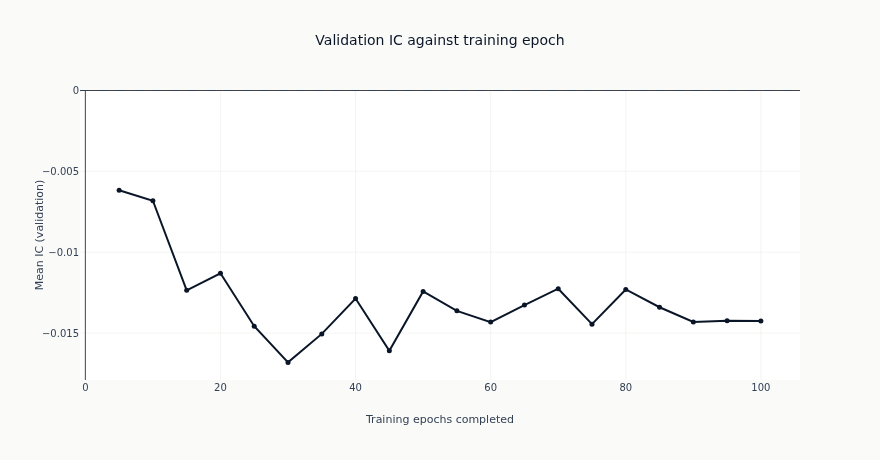

In [10]:
curve = catalog.filter("full_coverage").sort("label", "checkpoint_value")
fig = go.Figure()
for label in sorted(set(curve.get_column("label"))):
    rows = curve.filter(pl.col("label") == label).sort("checkpoint_value")
    fig.add_trace(
        go.Scatter(
            x=rows.get_column("checkpoint_value").to_list(),
            y=rows.get_column("ic_mean").to_list(),
            mode="lines+markers",
            name=label,
            line=dict(color=COLORS["blue"] if label == primary else COLORS["recede"], width=2),
            marker=dict(size=5),
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Mean IC (validation)")
fig.update_xaxes(title_text="Training epochs completed")
fig.update_layout(
    title="Validation IC against training epoch",
    height=460,
    width=880,
    margin=dict(t=90),
)
# The span of the line and where it sits relative to zero are facts about the frame, so the
# description counts them rather than asserting a shape the next run may not reproduce.
spans = "; ".join(
    "{} spans {:+.4f} to {:+.4f} with {} of {} checkpoints above zero".format(
        row["label"], row["lo"], row["hi"], row["above"], row["total"]
    )
    for row in curve.group_by("label")
    .agg(
        lo=pl.col("ic_mean").min(),
        hi=pl.col("ic_mean").max(),
        above=(pl.col("ic_mean") > 0).sum(),
        total=pl.len(),
    )
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Line chart of mean validation information coefficient against training epochs completed, one "
    f"line per fitted label with a dashed zero line. Counted from the frame: {spans}.",
)

## 5. What to notice

**A single-label population cannot separate the architecture from the target.** The rest of the
family is fitted on three labels, so a pattern that holds across all three there is evidence about
the architecture. Here there is one, and whatever this curve does is a statement about this
architecture on this target, jointly. Reading it as a statement about patched attention in
general takes more than one label's worth of evidence out of one label.

**The patch size is not searched.** One value is declared and one is fitted, so nothing here says
whether a coarser or finer patch reads this surface better. Adding a second preset and listing it
under the label's `deep_learning` menu is what would make that a question this notebook answers;
as it stands the patch size is a fixed assumption rather than a tested one.

**Nothing here is selected.** Every checkpoint is registered, and what advances is decided in
[`14_backtest`](14_backtest.ipynb) on validation backtest Sharpe after costs.

**Next**: [`11_latent_factors`](11_latent_factors.ipynb) turns to the latent-factor families, and
[`13_model_analysis`](13_model_analysis.ipynb) compares every family fitted so far.